# PRRSV ORF7 Start Rescue Experiment

This notebook tests the experimental CDS start-rescue logic on **ORF7 only**. It reruns `tblastn` from scratch for PRRSV strict-clean records that contain ORF7 in validation truth, then compares lifted ORF7 coordinates against same-gene truth.

Why ORF7: previous PRRSV breakdown showed a repeated pattern where ORF7 had `delta_end = 0` but `delta_start = +43/+48`, suggesting the tool found the correct end but rescued to an internal ATG instead of the true upstream start.

In [1]:
from pathlib import Path
import sys
import importlib

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'app').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import app.validation._shared.validation_utils as validation_utils
importlib.reload(validation_utils)
from app.validation._shared.validation_utils import (
    load_reference_bundle,
    load_genbank_records,
    parse_validation_truth_features,
    lifted_to_rows,
    compare_predictions_to_truth,
    summarize_comparison,
)
from app.src.lifting.tblastn_lifter import lift_all_tblastn

BASE_DIR = ROOT / 'app' / 'validation' / '04_tblastn_truth_breakdown_100seq' / 'tiers' / 'strict_clean'
INPUT_DIR = BASE_DIR / 'inputs'
OUTPUT_DIR = BASE_DIR / 'orf7_start_rescue_outputs'
DATA_DIR = ROOT / 'app' / 'data'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 120)
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10})

BASE_DIR, OUTPUT_DIR

(PosixPath('/Users/MacbookProCuaNminh/Desktop/Nminh-Code/Bio-Vin/Phase_2/viralift/app/validation/04_tblastn_truth_breakdown_100seq/tiers/strict_clean'),
 PosixPath('/Users/MacbookProCuaNminh/Desktop/Nminh-Code/Bio-Vin/Phase_2/viralift/app/validation/04_tblastn_truth_breakdown_100seq/tiers/strict_clean/orf7_start_rescue_outputs'))

## Load PRRSV Reference ORF7

The experiment lifts only the ORF7 reference CDS, so runtime is much shorter than a full PRRSV validation run.

In [2]:
bundle = load_reference_bundle(DATA_DIR / 'PRRS_ref_test.gb')
ref_record = bundle['record']
orf7_features = [feature for feature in bundle['features'] if feature['name'] == 'ORF7']
assert len(orf7_features) == 1, orf7_features

orf7_ref = pd.DataFrame(orf7_features).assign(
    ref_len=lambda d: d['end'] - d['start'] + 1,
)
orf7_ref

,type,name,start,end,strand,length,rel_start,rel_end,order,gene,product,label,standard_name,locus_tag,note,raw_name,name_source,ref_len
0,CDS,ORF7,14890,15261,+,372,0.96613,0.990202,9,None,nucleocapsid protein N,None,None,None,ORF7;N,nucleocapsid protein N,alias,372


## Select Query Records With ORF7 Truth

Accuracy denominator = records where validation truth actually contains ORF7. This keeps the test focused on cases with a same-gene answer.

In [3]:
manifest = pd.read_csv(INPUT_DIR / 'manifest.tsv', sep='	')
keep_ids = set(manifest[(manifest['virus'].eq('PRRS')) & (manifest['keep'].eq(True))]['record_id'])
query_records = load_genbank_records(INPUT_DIR / 'PRRS_records.gb')

truth_rows = []
records_with_orf7_truth = []
for record in query_records:
    if record.id not in keep_ids:
        continue
    truth_features, _ = parse_validation_truth_features(
        record,
        bundle['alias_lookup'],
        bundle['feature_type'],
        bundle['features'],
        'PRRS',
    )
    orf7_truth = [feature for feature in truth_features if feature['name'] == 'ORF7']
    if not orf7_truth:
        continue
    records_with_orf7_truth.append((record, orf7_truth))
    for feature in orf7_truth:
        truth_rows.append({
            'record_id': record.id,
            'truth_start': feature['start'],
            'truth_end': feature['end'],
            'truth_len': feature['end'] - feature['start'] + 1,
        })

truth_df = pd.DataFrame(truth_rows)
truth_df.to_csv(OUTPUT_DIR / 'orf7_truth_records.tsv', sep='	', index=False)
print('records_with_orf7_truth:', len(records_with_orf7_truth))
truth_df['truth_len'].value_counts().sort_index().rename_axis('truth_len').reset_index(name='records')

records_with_orf7_truth: 94


,truth_len,records
0,369,1
1,372,89
2,387,4


## Run ORF7 tblastn From Scratch

This cell runs `tblastn` for ORF7 against each query genome. It does not read cached comparison files.

In [4]:
rows = []
for idx, (record, orf7_truth) in enumerate(records_with_orf7_truth, start=1):
    lifted = lift_all_tblastn(
        orf7_features,
        ref_record,
        record,
        min_coverage=0.5,
        min_identity=0.3,
        rescue_window=50,
        validate_codons=True,
    )
    pred_rows = lifted_to_rows(record.id, lifted, 'tblastn_orf7_rescue_experiment')
    rows.append(compare_predictions_to_truth(pred_rows, orf7_truth))
    if idx % 10 == 0:
        print(f'processed {idx}/{len(records_with_orf7_truth)} ORF7 truth records')

orf7_df = pd.concat(rows, ignore_index=True)
orf7_df.to_csv(OUTPUT_DIR / 'orf7_rescue_vs_truth.tsv', sep='	', index=False)
orf7_df.head()

processed 10/94 ORF7 truth records


processed 20/94 ORF7 truth records


processed 30/94 ORF7 truth records


processed 40/94 ORF7 truth records


processed 50/94 ORF7 truth records


processed 60/94 ORF7 truth records


processed 70/94 ORF7 truth records


processed 80/94 ORF7 truth records


processed 90/94 ORF7 truth records


,record_id,method,ref_name,pred_name,source_name,pred_start,pred_end,strand,status,coverage,identity,score,truth_name,truth_start,truth_end,best_overlap_name,best_iou,iou,name_match,coord_correct,exact_match,failure_mode
0,AF184212.1,tblastn_orf7_rescue_experiment,ORF7,ORF7,None,14998,15369,+,ok,1.0,97.6,250.0,ORF7,14998,15369,ORF7,1.0,1.0,True,True,True,Correct
1,AF159149.1,tblastn_orf7_rescue_experiment,ORF7,ORF7,None,14865,15236,+,ok,1.0,99.2,254.6,ORF7,14865,15236,ORF7,1.0,1.0,True,True,True,Correct
2,AF325691.1,tblastn_orf7_rescue_experiment,ORF7,ORF7,None,14867,15238,+,ok,1.0,95.9,245.4,ORF7,14867,15238,ORF7,1.0,1.0,True,True,True,Correct
3,AY032626.1,tblastn_orf7_rescue_experiment,ORF7,ORF7,None,14890,15261,+,ok,1.0,95.9,247.7,ORF7,14890,15261,ORF7,1.0,1.0,True,True,True,Correct
4,AF494042.1,tblastn_orf7_rescue_experiment,ORF7,ORF7,None,14873,15244,+,ok,1.0,95.9,247.3,ORF7,14873,15244,ORF7,1.0,1.0,True,True,True,Correct


## Result Summary

Baseline comes from the previous PRRSV strict-clean breakdown before this experimental rescue change. The current result is generated by the cell above.

In [5]:
baseline = pd.DataFrame([
    {'run': 'baseline_previous_rescue', 'exact': 66, 'coord_correct': 66, 'total': 94},
])
current = pd.DataFrame([
    {
        'run': 'experimental_ref_length_start_rescue',
        'exact': int(orf7_df['exact_match'].sum()),
        'coord_correct': int(orf7_df['coord_correct'].sum()),
        'total': len(orf7_df),
    }
])
comparison = pd.concat([baseline, current], ignore_index=True)
comparison['exact_pct'] = (comparison['exact'] / comparison['total'] * 100).round(2)
comparison['coord_pct'] = (comparison['coord_correct'] / comparison['total'] * 100).round(2)
comparison['exact_delta_vs_baseline'] = comparison['exact'] - comparison.loc[0, 'exact']
comparison['coord_delta_vs_baseline'] = comparison['coord_correct'] - comparison.loc[0, 'coord_correct']
comparison.to_csv(OUTPUT_DIR / 'orf7_rescue_accuracy_comparison.tsv', sep='	', index=False)
comparison

,run,exact,coord_correct,total,exact_pct,coord_pct,exact_delta_vs_baseline,coord_delta_vs_baseline
0,baseline_previous_rescue,66,66,94,70.21,70.21,0,0
1,experimental_ref_length_start_rescue,91,91,94,96.81,96.81,25,25


In [6]:
status_summary = (
    orf7_df.groupby(['status', 'failure_mode'], dropna=False)
    .size()
    .reset_index(name='cases')
    .sort_values('cases', ascending=False)
)
status_summary.to_csv(OUTPUT_DIR / 'orf7_rescue_status_summary.tsv', sep='	', index=False)
status_summary

,status,failure_mode,cases
0,ok,Correct,65
1,ok_rescued,Correct,26
2,ok_rescued,Wrong coords,3


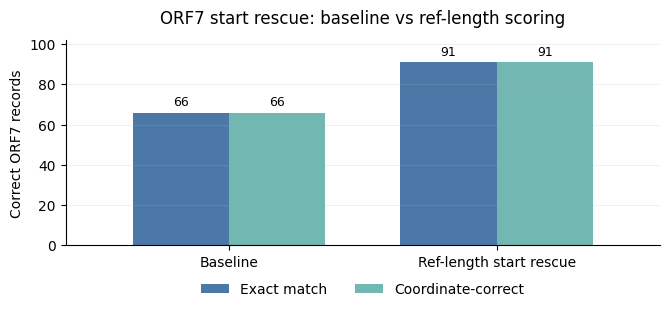

In [7]:
plot_df = comparison.copy()
plot_df['label'] = plot_df['run'].map({
    'baseline_previous_rescue': 'Baseline',
    'experimental_ref_length_start_rescue': 'Ref-length start rescue',
}).fillna(plot_df['run'])
plot_df = plot_df.set_index('label')[['exact', 'coord_correct']]

fig, ax = plt.subplots(figsize=(6.8, 3.6))
plot_df.plot(kind='bar', ax=ax, color=['#4C78A8', '#72B7B2'], width=0.72)
ax.set_ylim(0, comparison['total'].max() + 8)
ax.set_ylabel('Correct ORF7 records')
ax.set_xlabel('')
ax.set_title('ORF7 start rescue: baseline vs ref-length scoring', pad=12)
ax.legend(['Exact match', 'Coordinate-correct'], frameon=False, ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.12))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.18)
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)
plt.xticks(rotation=0, ha='center')
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig(OUTPUT_DIR / 'orf7_rescue_accuracy_comparison.png', bbox_inches='tight', dpi=160)
plt.show()

## Remaining Non-Exact Cases

After the experimental rescue, only the ORF7 records whose truth ORF7 is longer than the reference remain non-exact. These should be reviewed separately because ref-length rescue cannot infer a longer-than-ref truth boundary.

In [8]:
non_exact = orf7_df[~orf7_df['exact_match'].fillna(False)].copy()
for col in ['pred_start', 'pred_end', 'truth_start', 'truth_end']:
    non_exact[col] = pd.to_numeric(non_exact[col], errors='coerce')
non_exact['delta_start'] = non_exact['pred_start'] - non_exact['truth_start']
non_exact['delta_end'] = non_exact['pred_end'] - non_exact['truth_end']
non_exact['pred_len'] = non_exact['pred_end'] - non_exact['pred_start'] + 1
non_exact['truth_len'] = non_exact['truth_end'] - non_exact['truth_start'] + 1
non_exact['ref_len'] = int(orf7_ref['ref_len'].iloc[0])
non_exact['pred_minus_ref_len'] = non_exact['pred_len'] - non_exact['ref_len']
non_exact['truth_minus_ref_len'] = non_exact['truth_len'] - non_exact['ref_len']
non_exact.to_csv(OUTPUT_DIR / 'orf7_rescue_remaining_non_exact.tsv', sep='	', index=False)
non_exact[[
    'record_id', 'pred_start', 'pred_end', 'truth_start', 'truth_end',
    'delta_start', 'delta_end', 'ref_len', 'pred_len', 'truth_len',
    'pred_minus_ref_len', 'truth_minus_ref_len', 'status', 'coverage', 'identity', 'iou', 'failure_mode'
]]

,record_id,pred_start,pred_end,truth_start,truth_end,delta_start,delta_end,ref_len,pred_len,truth_len,pred_minus_ref_len,truth_minus_ref_len,status,coverage,identity,iou,failure_mode
8,AY366525.1,14595,14933,14547,14933,48,0,372,339,387,-33,15,ok_rescued,0.8943,64.5,0.876,Wrong coords
22,DQ489311.1,14595,14933,14547,14933,48,0,372,339,387,-33,15,ok_rescued,0.8943,64.5,0.876,Wrong coords
24,DQ864705.1,14569,14907,14521,14907,48,0,372,339,387,-33,15,ok_rescued,0.8943,64.5,0.876,Wrong coords


## Interpretation

The experimental rescue confirms the suspected mechanism: most ORF7 failures were caused by start rescue choosing an internal ATG near the HSP start. Adding ref-length-aware start candidate selection fixes the 25 cases where ref and truth both have a 372 bp ORF7.

The remaining 3 cases have `truth_len = 387`, while the reference ORF7 length is 372 bp. The experimental rescue intentionally does not extend beyond the reference length, so those cases remain for manual review / annotation-convention analysis.